In [1]:
print("hello")

hello


In [ ]:
!kaggle datasets download -d blourdhuraju/dogs-vs-cats-classification

Dataset URL: https://www.kaggle.com/datasets/blourdhuraju/dogs-vs-cats-classification
License(s): CC0-1.0
dogs-vs-cats-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip dogs-vs-cats-classification.zip

Archive:  dogs-vs-cats-classification.zip
replace dogs-vs-cats-classification/dataset_info.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
#verifying folders

import os

print(os.listdir("dogs-vs-cats-classification"))

['dataset_info.csv', 'train', 'validation', 'test']


In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout, RandomFlip, RandomRotation, RandomZoom

In [ ]:
#generators we have 1000s of images so RAM cant process it at once so we divide them in batches by using generators

In [ ]:
train_ds=keras.utils.image_dataset_from_directory(
    directory='/content/dogs-vs-cats-classification/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

validation_ds=keras.utils.image_dataset_from_directory(
    directory='/content/dogs-vs-cats-classification/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 19943 files belonging to 2 classes.
Found 2495 files belonging to 2 classes.


In [ ]:
import tensorflow as tf

#Normalise:- we are doing this bcz we want all pixel velues should be b/w 0 and 1 otherwise our result will not be good

def process(image,label):
  image=tf.cast(image/255. ,tf.float32)
  return image,label

train_ds=train_ds.map(process, num_parallel_calls=tf.data.AUTOTUNE).prefetch(buffer_size=tf.data.AUTOTUNE).ignore_errors()
validation_ds=validation_ds.map(process, num_parallel_calls=tf.data.AUTOTUNE).prefetch(buffer_size=tf.data.AUTOTUNE).ignore_errors()

In [ ]:
#now we will create our CNN model

#3 convolutional layer
#first layer --32 filters
#second layer--64 filters
#third layer --128 filters

model=Sequential()

# Data Augmentation layers
model.add(RandomFlip("horizontal", input_shape=(256,256,3)))
model.add(RandomRotation(0.1))
model.add(RandomZoom(0.1))

#we ned to give input shape in first layer later it will infer itself

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu')) # input_shape removed, handled by augmentation layers
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))
model.add(Dropout(0.2))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))
model.add(Dropout(0.3))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))
model.add(Dropout(0.4))

#flatten
model.add(Flatten())


#fully connceted layer
model.add(Dense(128,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(64,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,961 (56.64 MB)

 Trainable params: 14,848,129 (56.64 MB)

 Non-trainable params: 832 (3.25 KB)

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
    621/Unknown 75s 93ms/step - accuracy: 0.5726 - loss: 0.8021

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


621/621 ━━━━━━━━━━━━━━━━━━━━ 83s 106ms/step - accuracy: 0.6062 - loss: 0.7167 - val_accuracy: 0.6442 - val_loss: 0.6185
Epoch 2/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 54s 88ms/step - accuracy: 0.6956 - loss: 0.5727 - val_accuracy: 0.6664 - val_loss: 0.6314
Epoch 3/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 54s 88ms/step - accuracy: 0.7440 - loss: 0.5160 - val_accuracy: 0.6903 - val_loss: 0.5720
Epoch 4/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 54s 88ms/step - accuracy: 0.7836 - loss: 0.4589 - val_accuracy: 0.7799 - val_loss: 0.4597
Epoch 5/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 55s 89ms/step - accuracy: 0.8177 - loss: 0.4046 - val_accuracy: 0.7873 - val_loss: 0.4640
Epoch 6/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 98s 158ms/step - accuracy: 0.8462 - loss: 0.3499 - val_accuracy: 0.7927 - val_loss: 0.4669
Epoch 7/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.8734 - loss: 0.2947 - val_accuracy: 0.7869 - val_loss: 0.4642
Epoch 8/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.9010 - loss: 0.2395 - val_accur

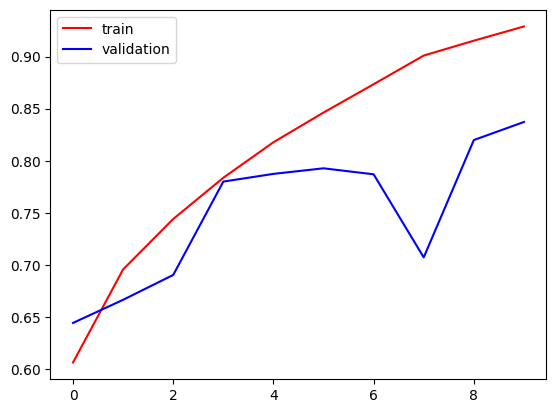

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

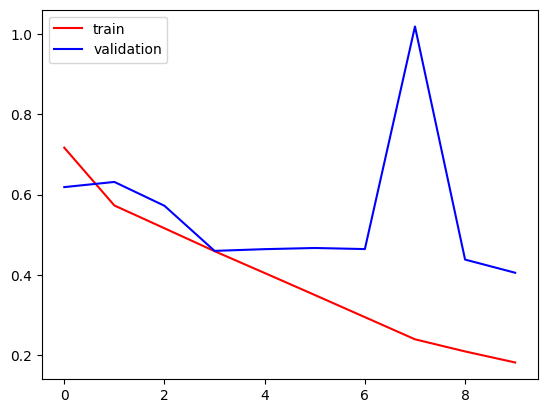

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
#ways to reduce overfitting

#add more data
#data augmentation
#L1/L2 regularizer
#Dropout
#batch Norm
#reduce complexity

In [ ]:
import cv2

In [ ]:
test_img=cv2.imread("/content/dog.jpg")

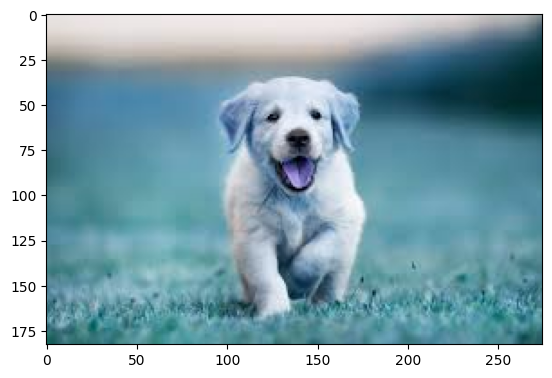

In [ ]:
plt.imshow(test_img)

In [ ]:
test_img.shape

(183, 275, 3)

In [ ]:
#resizing the image

test_img=cv2.resize(test_img,(256,256))

In [ ]:
test_input=test_img.reshape((1,256,256,3))

In [ ]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


array([[0.]], dtype=float32)

for cat

In [ ]:
test_img=cv2.imread("/content/cat.jpg")

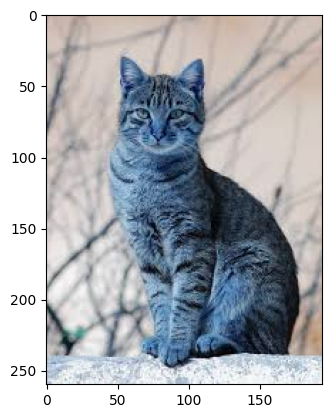

In [ ]:
plt.imshow(test_img)

In [ ]:
test_img.shape

(260, 194, 3)

In [ ]:
#resizing the image

test_img=cv2.resize(test_img,(256,256))

In [ ]:
test_input=test_img.reshape((1,256,256,3))

In [ ]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


array([[0.]], dtype=float32)